In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [2]:
results = pd.read_csv("../data/raw/results.csv")
pit_stops = pd.read_csv("../data/raw/pit_stops.csv")
qualifying = pd.read_csv("../data/raw/qualifying.csv")
races = pd.read_csv("../data/raw/races.csv")
drivers = pd.read_csv("../data/raw/drivers.csv")
constructors = pd.read_csv("../data/raw/constructors.csv")
circuits = pd.read_csv("../data/raw/circuits.csv")
lap_times = pd.read_csv("../data/raw/lap_times.csv")
driver_standings = pd.read_csv("../data/raw/driver_standings.csv")
constructor_standings = pd.read_csv("../data/raw/constructor_standings.csv")
status = pd.read_csv("../data/raw/status.csv")

In [3]:
datasets = {
    "results": results,
    "pit_stops": pit_stops,
    "qualifying": qualifying,
    "races": races,
    "drivers": drivers,
    "constructors": constructors,
    "circuits": circuits,
    "lap_times": lap_times,
    "driver_standings": driver_standings,
    "constructor_standings": constructor_standings,
    "status": status
}

for name, df in datasets.items():
    print(f"{name}: {df.shape}")

results: (26759, 18)
pit_stops: (11371, 7)
qualifying: (10494, 9)
races: (1125, 18)
drivers: (861, 9)
constructors: (212, 5)
circuits: (77, 9)
lap_times: (589081, 6)
driver_standings: (34863, 7)
constructor_standings: (13391, 7)
status: (139, 2)


In [4]:
races = races[races["year"] >= 2012]

In [5]:
races_renamed = races[[
    "raceId",
    "year",
    "name",
    "date",
    "circuitId"
]].rename(columns={
    "name": "race_name"
})

df = results.merge(
    races_renamed,
    on="raceId",
    how="inner"
)

In [6]:
drivers_renamed = drivers[[
    "driverId", 
    "forename", 
    "surname"
]]

df = df.merge(
    drivers_renamed,
    on="driverId",
    how="left"
)

df["driver_name"] = df["forename"] + " " + df["surname"]

In [7]:
constructors_renamed = constructors[[
    "constructorId", 
    "name"
]].rename(columns={
    "name": "constructor_name"
})

df = df.merge(
    constructors_renamed,
    on="constructorId",
    how="left"
)

In [8]:
circuits_renamed = circuits[[
    "circuitId", 
    "name", 
    "location", 
    "country"
]].rename(columns={
    "name": "circuit_name"
})

df = df.merge(
    circuits_renamed,
    on="circuitId",
    how="left"
)

In [9]:
df["positionOrder"] = pd.to_numeric(df["positionOrder"], errors="coerce")
df["grid"] = pd.to_numeric(df["grid"], errors="coerce")

df["position_change"] = df["grid"] - df["positionOrder"]

In [10]:
df.head()

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId,year,race_name,date,circuitId,forename,surname,driver_name,constructor_name,circuit_name,location,country,position_change
0,21232,860,18,1,3,2,1,1,1,25.0,58,1:34:09.565,5649565,56,1,1:29.187,214.053,1,2012,Australian Grand Prix,2012-03-18,1,Jenson,Button,Jenson Button,McLaren,Albert Park Grand Prix Circuit,Melbourne,Australia,1
1,21233,860,20,9,1,6,2,2,2,18.0,58,+2.139,5651704,57,2,1:29.417,213.503,1,2012,Australian Grand Prix,2012-03-18,1,Sebastian,Vettel,Sebastian Vettel,Red Bull,Albert Park Grand Prix Circuit,Melbourne,Australia,4
2,21234,860,1,1,4,1,3,3,3,15.0,58,+4.075,5653640,57,4,1:29.538,213.214,1,2012,Australian Grand Prix,2012-03-18,1,Lewis,Hamilton,Lewis Hamilton,McLaren,Albert Park Grand Prix Circuit,Melbourne,Australia,-2
3,21235,860,17,9,2,5,4,4,4,12.0,58,+4.547,5654112,57,3,1:29.438,213.452,1,2012,Australian Grand Prix,2012-03-18,1,Mark,Webber,Mark Webber,Red Bull,Albert Park Grand Prix Circuit,Melbourne,Australia,1
4,21236,860,4,6,5,12,5,5,5,10.0,58,+21.565,5671130,52,7,1:30.277,211.469,1,2012,Australian Grand Prix,2012-03-18,1,Fernando,Alonso,Fernando Alonso,Ferrari,Albert Park Grand Prix Circuit,Melbourne,Australia,7


In [11]:
df[[
    "year",
    "driver_name",
    "constructor_name",
    "grid",
    "positionOrder",
    "position_change"
]].head(20)

,year,driver_name,constructor_name,grid,positionOrder,position_change
0,2012,Jenson Button,McLaren,2,1,1
1,2012,Sebastian Vettel,Red Bull,6,2,4
2,2012,Lewis Hamilton,McLaren,1,3,-2
3,2012,Mark Webber,Red Bull,5,4,1
4,2012,Fernando Alonso,Ferrari,12,5,7
5,2012,Kamui Kobayashi,Sauber,13,6,7
6,2012,Kimi Räikkönen,Lotus F1,17,7,10
7,2012,Sergio Pérez,Sauber,22,8,14
8,2012,Daniel Ricciardo,Toro Rosso,10,9,1
9,2012,Paul di Resta,Force India,15,10,5


In [12]:
df.isnull().sum().sort_values(ascending=False).head(20)

resultId           0
raceId             0
driverId           0
constructorId      0
number             0
grid               0
position           0
positionText       0
positionOrder      0
points             0
laps               0
time               0
milliseconds       0
fastestLap         0
rank               0
fastestLapTime     0
fastestLapSpeed    0
statusId           0
year               0
race_name          0
dtype: int64

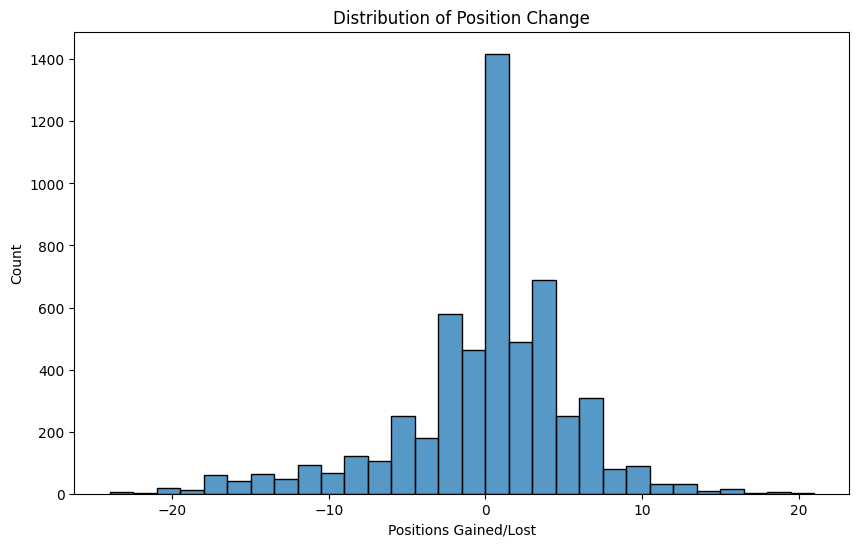

In [13]:
plt.figure(figsize=(10,6))
sns.histplot(df["position_change"], bins=30)

plt.title("Distribution of Position Change")
plt.xlabel("Positions Gained/Lost")
plt.ylabel("Count")

plt.savefig(
    "../figures/position_change_distribution.png",
    bbox_inches="tight"
)

plt.show()

In [14]:
pit_stops.head()

,raceId,driverId,stop,lap,time,duration,milliseconds
0,841,153,1,1,17:05:23,26.898,26898
1,841,30,1,1,17:05:52,25.021,25021
2,841,17,1,11,17:20:48,23.426,23426
3,841,4,1,12,17:22:34,23.251,23251
4,841,13,1,13,17:24:10,23.842,23842


In [15]:
pit_stops.columns.tolist()

['raceId', 'driverId', 'stop', 'lap', 'time', 'duration', 'milliseconds']

In [16]:
pit_stops["milliseconds"] = pd.to_numeric(
    pit_stops["milliseconds"],
    errors="coerce"
)

In [17]:
pit_features = pit_stops.groupby(
    ["raceId", "driverId"]
).agg({
    "stop": "count",
    "lap": ["min", "max", "mean"],
    "milliseconds": ["mean", "sum", "std"]
})

In [18]:
pit_features.columns = [
    "num_pit_stops",
    "first_pit_lap",
    "last_pit_lap",
    "avg_pit_lap",
    "avg_pit_duration",
    "total_pit_duration",
    "pit_duration_std"
]

pit_features = pit_features.reset_index()

In [19]:
pit_features.head()

,raceId,driverId,num_pit_stops,first_pit_lap,last_pit_lap,avg_pit_lap,avg_pit_duration,total_pit_duration,pit_duration_std
0,841,1,2,16,36,26.0,23213.0,46426,19.798990
1,841,2,2,15,30,22.5,24046.0,48092,1487.752668
2,841,3,1,16,16,16.0,23716.0,23716,NaN
3,841,4,3,12,42,27.0,24055.0,72165,748.991322
4,841,5,1,17,17,17.0,24865.0,24865,NaN


In [20]:
df = df.merge(
    pit_features,
    on=["raceId", "driverId"],
    how="left"
)

In [21]:
df[[
    "num_pit_stops",
    "avg_pit_duration",
    "first_pit_lap"
]].isnull().sum()

num_pit_stops       378
avg_pit_duration    378
first_pit_lap       378
dtype: int64

In [22]:
pit_columns = [
    "num_pit_stops",
    "first_pit_lap",
    "last_pit_lap",
    "avg_pit_lap",
    "avg_pit_duration",
    "total_pit_duration",
    "pit_duration_std"
]

df[pit_columns] = df[pit_columns].fillna(0)

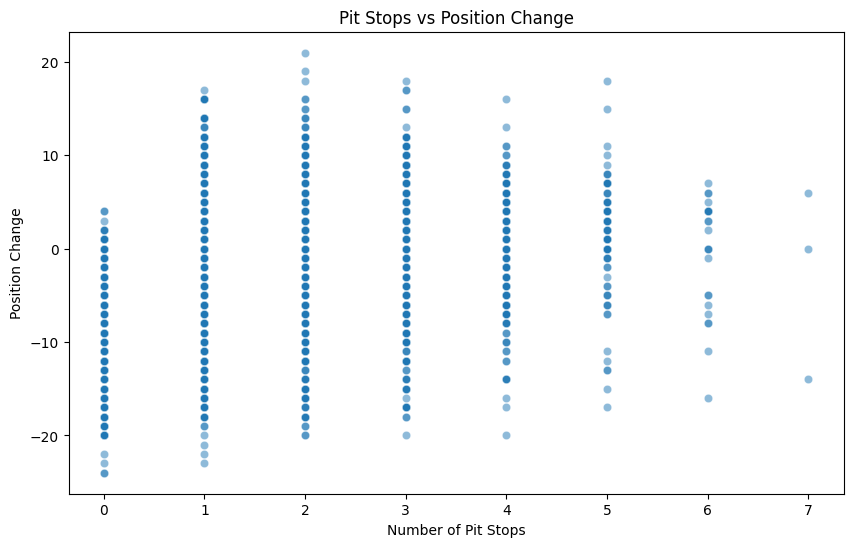

In [23]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="num_pit_stops",
    y="position_change",
    alpha=0.5
)

plt.title("Pit Stops vs Position Change")
plt.xlabel("Number of Pit Stops")
plt.ylabel("Position Change")

plt.savefig(
    "../figures/pit_stops_vs_position_change.png",
    bbox_inches="tight"
)

plt.show()

In [24]:
qualifying.head()

,qualifyId,raceId,driverId,constructorId,number,position,q1,q2,q3
0,1,18,1,1,22,1,1:26.572,1:25.187,1:26.714
1,2,18,9,2,4,2,1:26.103,1:25.315,1:26.869
2,3,18,5,1,23,3,1:25.664,1:25.452,1:27.079
3,4,18,13,6,2,4,1:25.994,1:25.691,1:27.178
4,5,18,2,2,3,5,1:25.960,1:25.518,1:27.236


In [25]:
qualifying.columns.tolist()

['qualifyId',
 'raceId',
 'driverId',
 'constructorId',
 'number',
 'position',
 'q1',
 'q2',
 'q3']

In [26]:
qualifying_features = qualifying[[
    "raceId",
    "driverId",
    "position"
]].copy()

qualifying_features.rename(
    columns={"position": "qualifying_position"},
    inplace=True
)

In [27]:
df = df.merge(
    qualifying_features,
    on=["raceId", "driverId"],
    how="left"
)

In [28]:
df["qualifying_position"] = pd.to_numeric(
    df["qualifying_position"],
    errors="coerce"
)

In [29]:
df["qualifying_position"] = pd.to_numeric(
    df["qualifying_position"],
    errors="coerce"
)

In [30]:
df["qualifying_position"].isnull().sum()

np.int64(20)

In [31]:
df["qualifying_position"] = df[
    "qualifying_position"
].fillna(df["grid"])

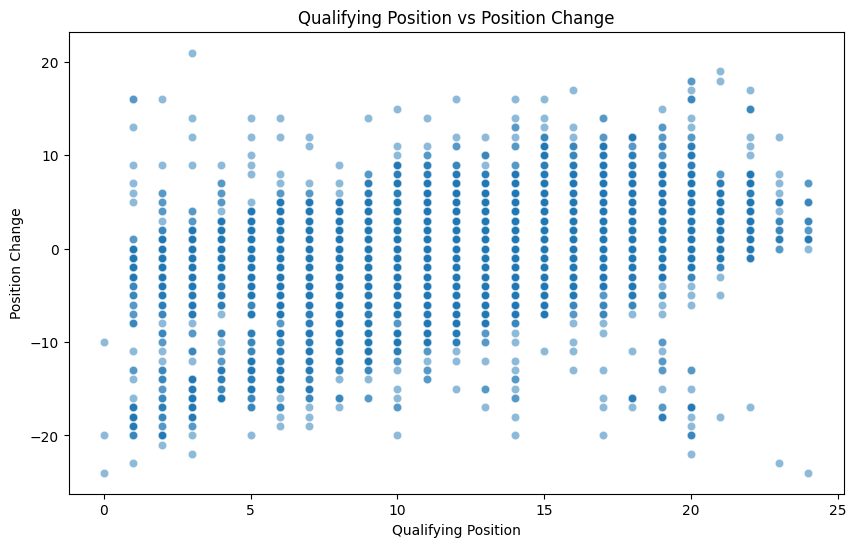

In [32]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="qualifying_position",
    y="position_change",
    alpha=0.5
)

plt.title("Qualifying Position vs Position Change")
plt.xlabel("Qualifying Position")
plt.ylabel("Position Change")

plt.savefig(
    "../figures/qualifying_vs_position_change.png",
    bbox_inches="tight"
)

plt.show()

In [33]:
lap_times.head()

,raceId,driverId,lap,position,time,milliseconds
0,841,20,1,1,1:38.109,98109
1,841,20,2,1,1:33.006,93006
2,841,20,3,1,1:32.713,92713
3,841,20,4,1,1:32.803,92803
4,841,20,5,1,1:32.342,92342


In [34]:
lap_times.columns.tolist()

['raceId', 'driverId', 'lap', 'position', 'time', 'milliseconds']

In [35]:
lap_times["milliseconds"] = pd.to_numeric(
    lap_times["milliseconds"],
    errors="coerce"
)

In [36]:
lap_features = lap_times.groupby(
    ["raceId", "driverId"]
).agg({
    "milliseconds": ["mean", "std", "min", "max"],
    "lap": "max"
})

In [37]:
lap_features.columns = [
    "avg_lap_time",
    "lap_time_std",
    "fastest_lap_time",
    "slowest_lap_time",
    "total_laps_completed"
]

lap_features = lap_features.reset_index()

In [38]:
lap_features.head()

,raceId,driverId,avg_lap_time,lap_time_std,fastest_lap_time,slowest_lap_time,total_laps_completed
0,1,1,97563.758621,16066.158258,89020,153309,58
1,1,2,97635.672414,14275.663645,88283,157754,58
2,1,3,97612.172414,16311.606142,87706,155699,58
3,1,4,97597.637931,16337.006698,88712,153045,58
4,1,6,91822.235294,3476.084499,89923,104899,17


In [39]:
df = df.merge(
    lap_features,
    on=["raceId", "driverId"],
    how="left"
)

In [40]:
df[[
    "avg_lap_time",
    "lap_time_std",
    "fastest_lap_time"
]].isnull().sum()

avg_lap_time        163
lap_time_std        217
fastest_lap_time    163
dtype: int64

In [41]:
lap_columns = [
    "avg_lap_time",
    "lap_time_std",
    "fastest_lap_time",
    "slowest_lap_time",
    "total_laps_completed"
]

for col in lap_columns:
    df[col] = df[col].fillna(df[col].median())

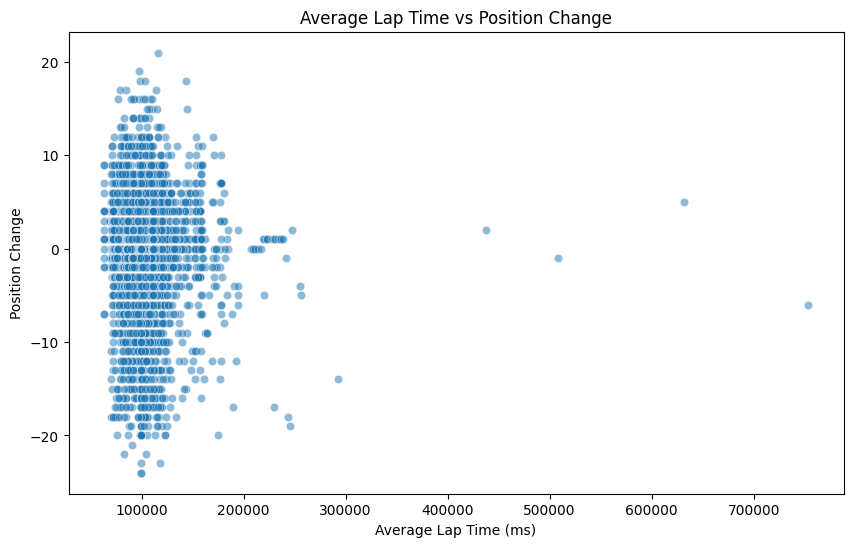

In [42]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="avg_lap_time",
    y="position_change",
    alpha=0.5
)

plt.title("Average Lap Time vs Position Change")
plt.xlabel("Average Lap Time (ms)")
plt.ylabel("Position Change")

plt.show()

In [43]:
df["avg_lap_time"].describe()

count      5524.000000
mean     100978.359702
std       24370.355870
min       62932.344828
25%       87048.248774
50%       99039.730769
75%      108451.575359
max      753493.000000
Name: avg_lap_time, dtype: float64

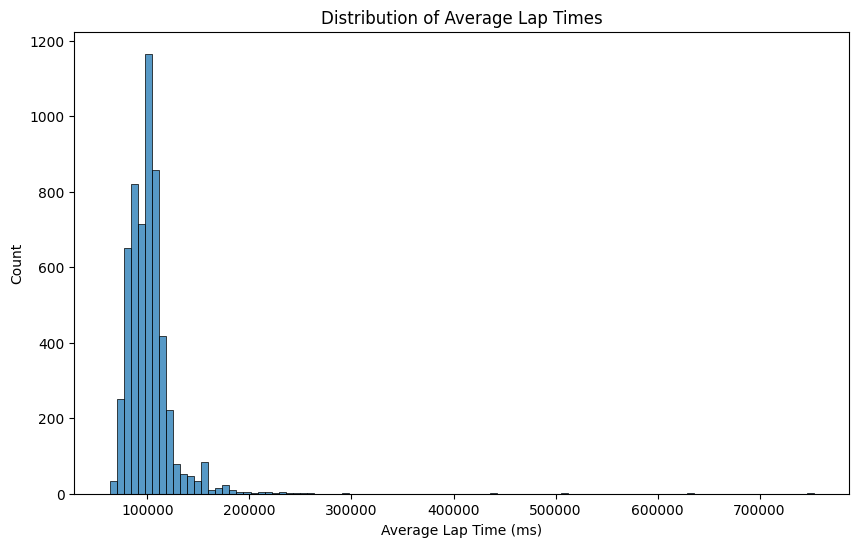

In [44]:
plt.figure(figsize=(10,6))

sns.histplot(df["avg_lap_time"], bins=100)

plt.title("Distribution of Average Lap Times")
plt.xlabel("Average Lap Time (ms)")

plt.show()

In [45]:
df = df[df["avg_lap_time"] < 200000]

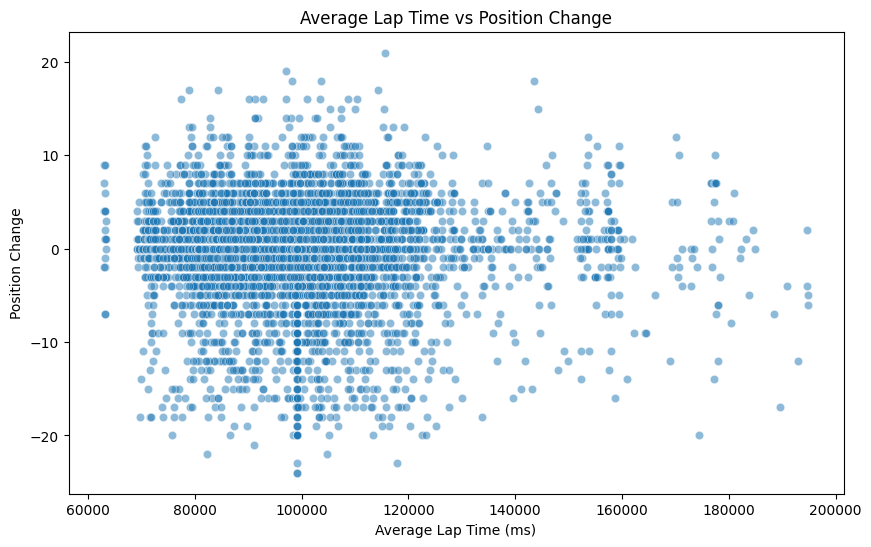

In [46]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="avg_lap_time",
    y="position_change",
    alpha=0.5
)

plt.title("Average Lap Time vs Position Change")
plt.xlabel("Average Lap Time (ms)")
plt.ylabel("Position Change")

plt.savefig(
    "../figures/lap_time_vs_position_change.png",
    bbox_inches="tight"
)

plt.show()

In [47]:
df.shape

(5494, 43)

In [48]:
model_df = df[[
    "position_change",

    "grid",
    "qualifying_position",

    "num_pit_stops",
    "first_pit_lap",
    "last_pit_lap",
    "avg_pit_lap",
    "avg_pit_duration",
    "total_pit_duration",

    "avg_lap_time",
    "lap_time_std",
    "fastest_lap_time",
    "total_laps_completed",

    "constructor_name",
    "circuit_name"
]].copy()

In [49]:
model_df.isnull().sum()

position_change         0
grid                    0
qualifying_position     0
num_pit_stops           0
first_pit_lap           0
last_pit_lap            0
avg_pit_lap             0
avg_pit_duration        0
total_pit_duration      0
avg_lap_time            0
lap_time_std            0
fastest_lap_time        0
total_laps_completed    0
constructor_name        0
circuit_name            0
dtype: int64

In [50]:
model_df = pd.get_dummies(
    model_df,
    columns=[
        "constructor_name",
        "circuit_name"
    ],
    drop_first=True
)

In [51]:
X = model_df.drop(columns=["position_change"])
y = model_df["position_change"]

In [52]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [53]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

lr_predictions = lr.predict(X_test)

In [54]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

lr_mae = mean_absolute_error(y_test, lr_predictions)

lr_rmse = np.sqrt(
    mean_squared_error(y_test, lr_predictions)
)

lr_r2 = r2_score(y_test, lr_predictions)

print("Linear Regression Results")
print("MAE:", lr_mae)
print("RMSE:", lr_rmse)
print("R²:", lr_r2)

Linear Regression Results
MAE: 2.979847591363344
RMSE: 3.9119181264447542
R²: 0.5693168428151527


In [55]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_predictions = rf.predict(X_test)

In [56]:
rf_mae = mean_absolute_error(y_test, rf_predictions)

rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_predictions)
)

rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest Results")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R²:", rf_r2)

Random Forest Results
MAE: 2.4387443130118287
RMSE: 3.352072763341666
R²: 0.683768411866218


In [57]:
feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

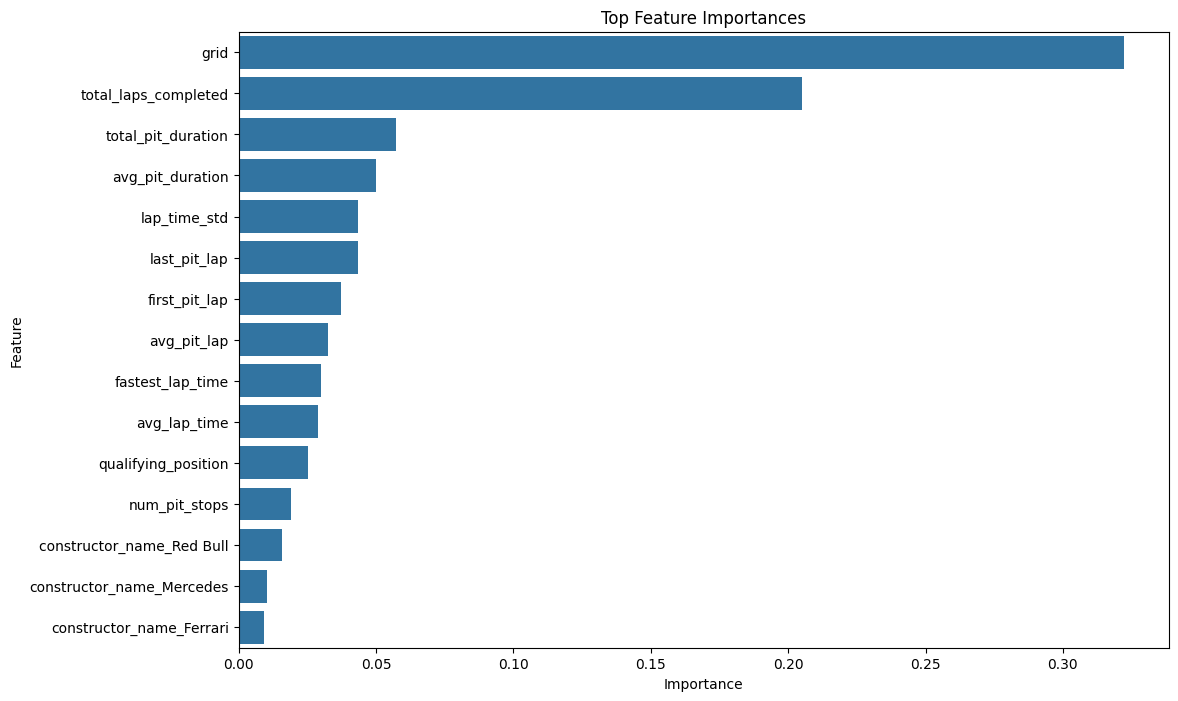

In [58]:
top_features = feature_importance.head(15)

plt.figure(figsize=(12,8))

sns.barplot(
    data=top_features,
    x="importance",
    y="feature"
)

plt.title("Top Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.savefig(
    "../figures/feature_importance.png",
    bbox_inches="tight"
)

plt.show()

In [59]:
df.to_csv(
    "../data/processed/f1_pit_strategy_model_data.csv",
    index=False
)

feature_importance.to_csv(
    "../data/processed/feature_importance.csv",
    index=False
)

In [60]:
import joblib

joblib.dump(
    rf,
    "../models/random_forest_model.pkl"
)

['../models/random_forest_model.pkl']

In [61]:
results_df = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        lr_mae,
        rf_mae
    ],
    "RMSE": [
        lr_rmse,
        rf_rmse
    ],
    "R2": [
        lr_r2,
        rf_r2
    ]
})

results_df

,Model,MAE,RMSE,R2
0,Linear Regression,2.979848,3.911918,0.569317
1,Random Forest,2.438744,3.352073,0.683768


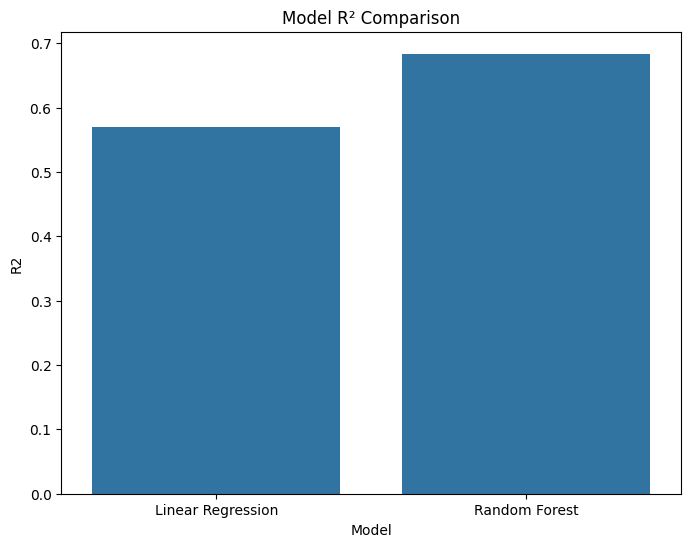

In [62]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=results_df,
    x="Model",
    y="R2"
)

plt.title("Model R² Comparison")

plt.savefig(
    "../figures/model_comparison.png",
    bbox_inches="tight"
)

plt.show()

In [63]:
import joblib

joblib.dump(
    X.columns.tolist(),
    "../models/model_columns.pkl"
)

['../models/model_columns.pkl']